In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from walkforward_parameter_search import compute_grid_size
from synthetic_returns import estimate_marginal_stats, synthesize_returns
set_config(transform_output="pandas")
init_logger("CSCV_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\CSCV_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
log_print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


In [3]:
from cscv_pbo import cscv_pbo,plot_cscv

In [ ]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.9, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.9, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 252}}  # inner train size
log_print(search_space, section='Search Space', echo=False)
compute_grid_size(search_space)

3

In [39]:
cscv_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 8,
  'n_trials': 2000,
  'patience': 200,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'seed': 42,
  'inner_purged_size': 2,
  'inner_embargo_size': 2,
  'candidate_mode': 'all',
  'top_k': 50,
  'S': 16,
  'verbose': True}
log_print(cscv_params, section='Parameter Space', echo=False)

In [40]:
out = cscv_pbo(X, space=search_space, **cscv_params)   # 空间缺省载自 TOML    

  0%|          | 0/2000 [00:00<?, ?it/s]

  收益流构建：105 参数 x 6 块 x 252 天 = 1512 天


收益流构建:   0%|          | 0/105 [00:00<?, ?候选/s]

In [41]:
log_print( out["report"], section="CSCV PBO 诊断", echo=True)

       CSCV PBO 诊断（标准版：单次搜索 + 静态参数族）
  搜索：trials=2000 | sampler=tpe | 候选 all = 105 | 搜索段 1008 天
  收益流：105 参数 x 6 块 x 252 天 = 1512 天
  评估区：2020-02-27 00:00:00+08:00 ~ 2026-05-25 00:00:00+08:00
  CSCV：S=16 块（每块 94 天）| 组合数 C(16,8) = 12870
  PBO = freq(lambda<=0) = 11.3%（1458/12870）
  lambda 分位：5%=-0.79 | 50%=+1.97 | 95%=+3.95
  IS 冠军多样性：32/105 个不同候选被选为冠军
  解读：PBO 越接近 0 排名传递性越好；>50% 严重预警（IS 最优比随机挑还不可信）


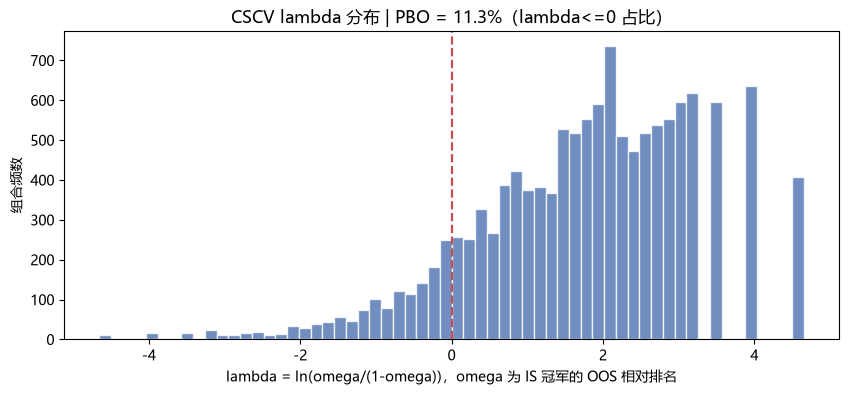

In [42]:
plot_cscv(out)                                          # lambda 分布图

#### 复用搜索结果

实验 1（窗效应，最有信息量）：固定本轮这 108 个候选，把评估窗扩回含 2020-02 ~ 2021-02。做法：把数据准备 cell 的过滤临时改回 >2015 重跑得到 X_long，然后：

In [ ]:
import importlib, cscv_pbo as m
importlib.reload(m)

M = m.build_returns_matrix(X, out["candidates"], start=cscv_params['train_size'],
                           block_size=cscv_params['test_size'])
core = m.cscv_core(M.to_numpy(), S=16)
print(f"PBO（窗含 2020-02~2021-02）= {core['pbo']:.1%}")

实验 2（挖"全能者"）：看是谁在霸榜：

In [43]:
vc = pd.Series(out["n_star"]).value_counts()
print(vc.head(8))
for idx in vc.head(3).index: print(int(vc[idx]), out["candidates"][idx])

91    4438
86    2510
7     2437
13     934
85     558
19     449
24     348
16     274
Name: count, dtype: int64
4438 {'nondomin__min_n_assets': 50, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-mad-avgdd-cvar-sharpe', 'train_size': 252}
2510 {'nondomin__min_n_assets': 50, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-mad-maxdd-cvar-sharpe', 'train_size': 252}
2437 {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.2, 'extremes__k': 0.8, 'nondomin__fitness_measures': 'mean-mad-avgdd-kurt', 'train_size': 504}
